# Experiment 6 — Per-Phase Query Budget Profiling

Measure exactly how many queries each phase consumes on the 200-image set,
for both models. Profiles front-loading: at which query the best L2 was first found.

In [1]:
import sys, os
from pathlib import Path

_candidates = [Path.cwd(), Path.cwd()/'STAGE_2', Path.cwd()/'Adversial ML'/'STAGE_2']
for _p in _candidates:
    if (_p / 'utils_stage2.py').exists():
        sys.path.insert(0, str(_p.resolve())); break
else:
    raise FileNotFoundError('utils_stage2.py not found')

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from utils_stage2 import (
    clip01, compute_ssim, compute_l2, compute_linf,
    Oracle, load_models, get_jointly_correct,
    phase1, phase2, build_subspace_with_dc, sep_cmaes,
    SSIM_STOP, H, W, C, N_IMAGES, RANDOM_SEED,
)

np.random.seed(RANDOM_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
P3_BUDGET = 1000
LAM = 10
os.makedirs('outputs/exp6', exist_ok=True)

Device: cpu


In [2]:
model_std, model_rob = load_models(device)
images = get_jointly_correct(model_std, model_rob, device, n=N_IMAGES)
B = build_subspace_with_dc(k_dct=20, k_sp=20)   # DC-inclusive
k = B.shape[0]
print(f'Images: {len(images)}   k={k}')

Images: 200   k=40


## Per-image pipeline profiling

In [3]:
def run_profiled(model, img_hwc, label, B, seed=0):
    oracle = Oracle(model, label, device)
    x_bnd, winner = phase1(oracle, img_hwc, seed=seed)
    if x_bnd is None:
        return None
    q_p1 = oracle.phase_count.get("p1", 0)
    l2_p1 = compute_l2(img_hwc, x_bnd)
    ssim_p1 = compute_ssim(img_hwc, x_bnd)
    x_bnd = phase2(oracle, img_hwc, x_bnd)
    q_p2 = oracle.phase_count.get("p2", 0)
    l2_p2 = compute_l2(img_hwc, x_bnd)
    ssim_p2 = compute_ssim(img_hwc, x_bnd)
    best_x, best_l2, best_ssim, _, history = sep_cmaes(
        oracle, img_hwc, x_bnd, B, lam=LAM, max_queries=P3_BUDGET)
    q_p3 = oracle.phase_count.get("p3", 0)
    first_best_q = q_p3
    for h in history:
        if abs(h["best_l2"] - best_l2) < 1e-9:
            first_best_q = h["queries"]
            break
    return dict(
        winner=winner, q_p1=q_p1, q_p2=q_p2, q_p3=q_p3,
        q_total=oracle.total, l2_p1=l2_p1, l2_p2=l2_p2, l2_p3=best_l2,
        ssim_p1=ssim_p1, ssim_p2=ssim_p2, ssim_p3=best_ssim,
        early_stopped=(best_ssim >= SSIM_STOP), first_best_q=first_best_q,
    )

In [4]:
MODELS = [('standard', model_std), ('robust', model_rob)]
all_profiles = {}
for model_name, model in MODELS:
    print(f'\n{model_name} ...')
    profs = []
    for i, rec in enumerate(images):
        profs.append(run_profiled(model, rec['img'], rec['label'], B, seed=rec['idx']))
        if (i+1) % 25 == 0:
            v = [p for p in profs if p]
            print(f'  {i+1}/{len(images)}  med_qtotal={np.median([p["q_total"] for p in v]):.0f}')
    all_profiles[model_name] = profs
    v = [p for p in profs if p]
    print(f'  Done: {len(v)}/{len(images)} succeeded')


standard ...
  25/200  med_qtotal=199
  50/200  med_qtotal=324
  75/200  med_qtotal=498
  100/200  med_qtotal=324
  125/200  med_qtotal=204
  150/200  med_qtotal=186
  175/200  med_qtotal=199
  200/200  med_qtotal=194
  Done: 155/200 succeeded

robust ...
  25/200  med_qtotal=1038
  50/200  med_qtotal=1038
  75/200  med_qtotal=1038
  100/200  med_qtotal=1038
  125/200  med_qtotal=1038
  150/200  med_qtotal=1038
  175/200  med_qtotal=1038
  200/200  med_qtotal=1038
  Done: 167/200 succeeded


## Summary statistics

In [5]:
header = f"{'Metric':<30} {'standard':>16} {'robust':>16}"
print(header)
print('-' * len(header))
for key, label in [
    ('q_p1',   'Queries Phase 1'),
    ('q_p2',   'Queries Phase 2'),
    ('q_p3',   'Queries Phase 3'),
    ('q_total','Total queries'),
    ('l2_p2',  'L2 after Phase 2'),
    ('l2_p3',  'L2 after Phase 3'),
    ('ssim_p3','SSIM after Phase 3'),
]:
    row = []
    for mn in ['standard', 'robust']:
        vals = [p[key] for p in all_profiles[mn] if p]
        med = np.median(vals)
        iqr = np.percentile(vals, 75) - np.percentile(vals, 25)
        row.append(f'{med:.2f} +/-{iqr:.2f}')
    print(f'{label:<30} {row[0]:>16} {row[1]:>16}')

for mn in ['standard', 'robust']:
    v = [p for p in all_profiles[mn] if p]
    e = sum(1 for p in v if p['early_stopped'])
    print(f'{mn}: {e}/{len(v)} ({100*e/len(v):.1f}%) SSIM early-stop')

Metric                                 standard           robust
----------------------------------------------------------------
Queries Phase 1                  30.00 +/-26.00   30.00 +/-13.00
Queries Phase 2                   21.00 +/-0.00    21.00 +/-0.00
Queries Phase 3                140.00 +/-990.00 1000.00 +/-295.00
Total queries                  194.00 +/-964.00 1038.00 +/-288.50
L2 after Phase 2                   4.37 +/-6.01     8.65 +/-8.14
L2 after Phase 3                   2.58 +/-2.48     4.01 +/-3.29
SSIM after Phase 3                 0.95 +/-0.06     0.89 +/-0.13
standard: 100/155 (64.5%) SSIM early-stop
robust: 50/167 (29.9%) SSIM early-stop


## Plot 1 — Stacked bar chart

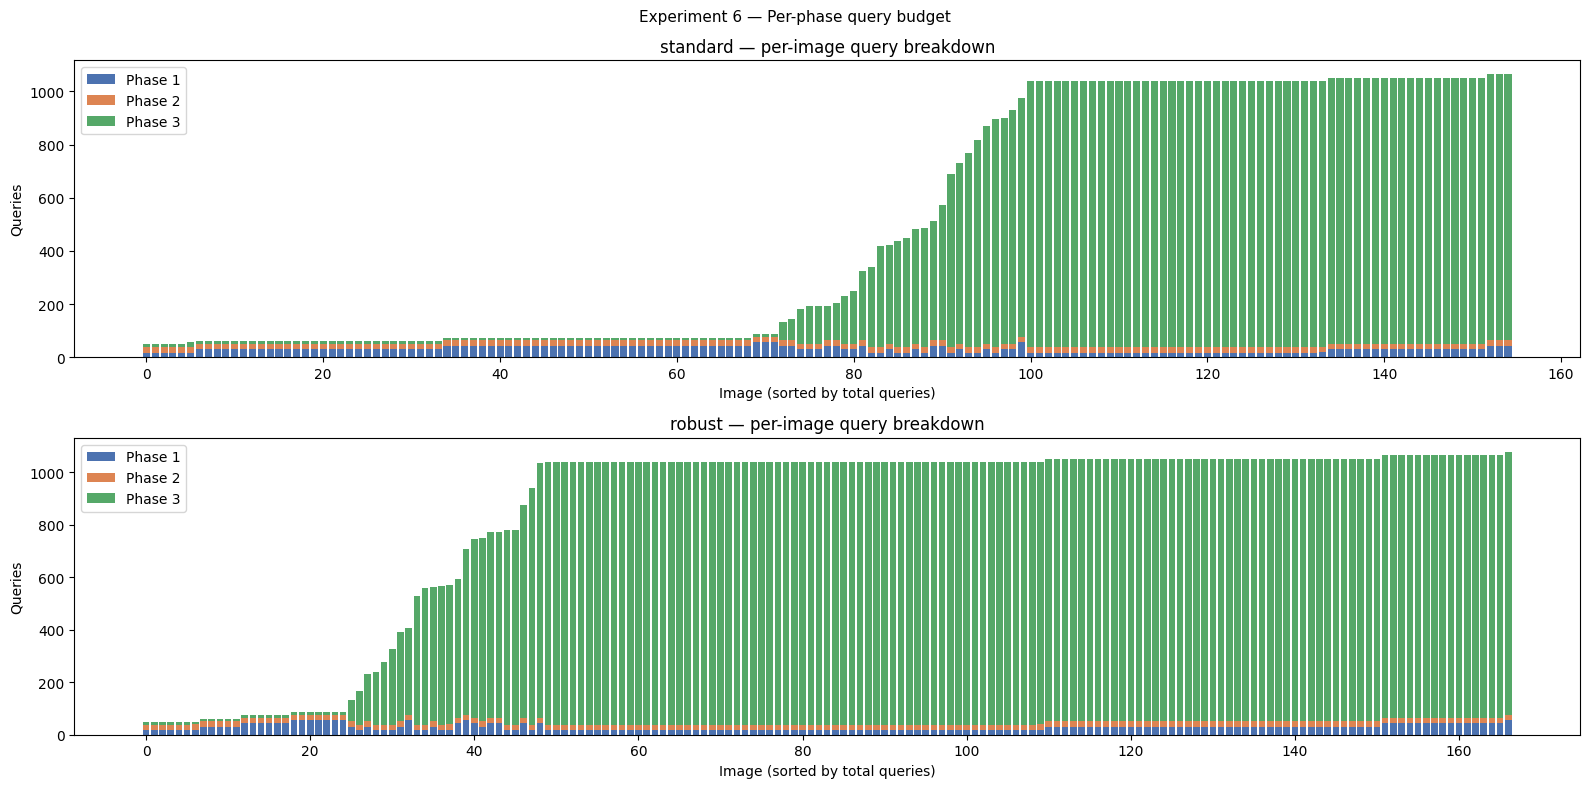

In [6]:
fig, axes = plt.subplots(2,1,figsize=(16,8))
for ax, mn in zip(axes,["standard","robust"]):
    v = sorted([p for p in all_profiles[mn] if p], key=lambda p: p["q_total"])
    x = np.arange(len(v))
    qp1=np.array([p["q_p1"] for p in v])
    qp2=np.array([p["q_p2"] for p in v])
    qp3=np.array([p["q_p3"] for p in v])
    ax.bar(x,qp1,label="Phase 1",color="#4C72B0")
    ax.bar(x,qp2,bottom=qp1,label="Phase 2",color="#DD8452")
    ax.bar(x,qp3,bottom=qp1+qp2,label="Phase 3",color="#55A868")
    ax.set_xlabel("Image (sorted by total queries)")
    ax.set_ylabel("Queries")
    ax.set_title(f"{mn} — per-image query breakdown")
    ax.legend()
    ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
plt.suptitle("Experiment 6 — Per-phase query budget",fontsize=11)
plt.tight_layout()
plt.savefig("outputs/exp6/stacked_bar.png",dpi=150)
plt.show()

## Plot 2 — Histograms per phase

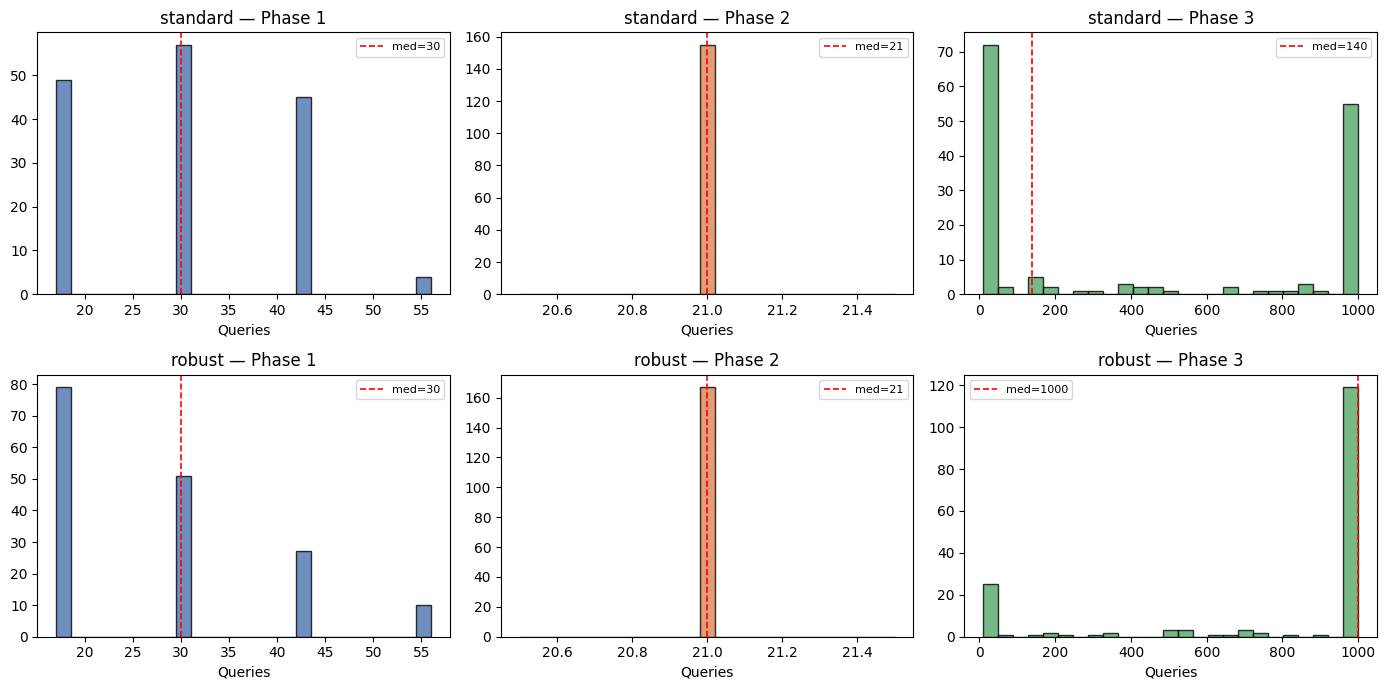

In [7]:
fig,axes=plt.subplots(2,3,figsize=(14,7))
COLS={"q_p1":"#4C72B0","q_p2":"#DD8452","q_p3":"#55A868"}
LBLS={"q_p1":"Phase 1","q_p2":"Phase 2","q_p3":"Phase 3"}
for row,mn in enumerate(["standard","robust"]):
    v=[p for p in all_profiles[mn] if p]
    for col,ph in enumerate(["q_p1","q_p2","q_p3"]):
        ax=axes[row][col]
        vals=[p[ph] for p in v]
        ax.hist(vals,bins=25,color=COLS[ph],edgecolor="k",alpha=0.8)
        ax.axvline(np.median(vals),color="red",ls="--",lw=1.2,label=f"med={np.median(vals):.0f}")
        ax.set_title(f"{mn} — {LBLS[ph]}")
        ax.set_xlabel("Queries")
        ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("outputs/exp6/histograms_per_phase.png",dpi=150)
plt.show()

## Plot 3 — Front-loading analysis

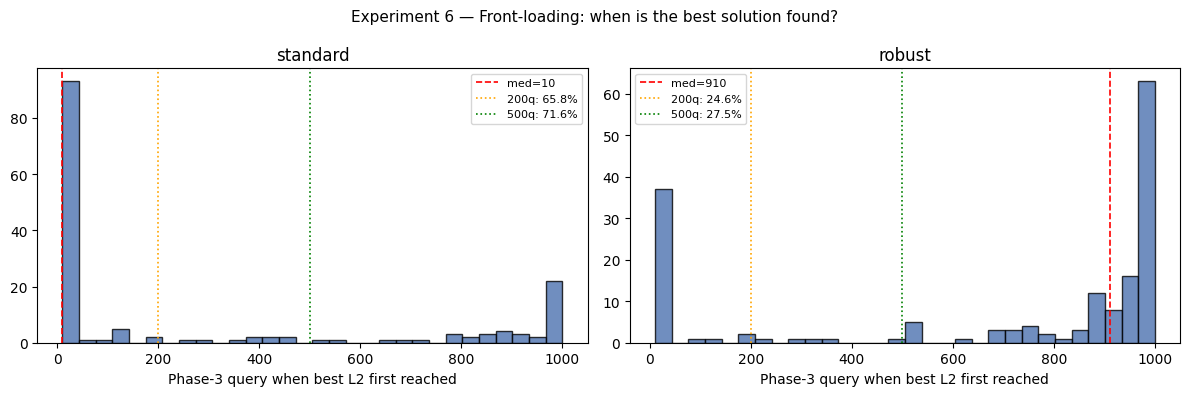

Experiment 6 complete.


In [8]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,mn in zip(axes,["standard","robust"]):
    v=[p for p in all_profiles[mn] if p]
    fq=np.array([p["first_best_q"] for p in v])
    ax.hist(fq,bins=30,edgecolor="k",alpha=0.8,color="#4C72B0")
    ax.axvline(np.median(fq),color="red",ls="--",lw=1.2,label=f"med={np.median(fq):.0f}")
    for bm,bc in [(200,"orange"),(500,"green")]:
        pct=100*(fq<=bm).mean()
        ax.axvline(bm,color=bc,ls=":",lw=1.2,label=f"{bm}q: {pct:.1f}%")
    ax.set_xlabel("Phase-3 query when best L2 first reached")
    ax.set_title(f"{mn}")
    ax.legend(fontsize=8)
plt.suptitle("Experiment 6 — Front-loading: when is the best solution found?",fontsize=11)
plt.tight_layout()
plt.savefig("outputs/exp6/front_loading.png",dpi=150)
plt.show()
print("Experiment 6 complete.")